# 🌲 Isolation Forest — Détection de Fraudes Financières
**ML Engineer 2** | Modèle non supervisé de détection d'anomalies

---
### Flux de travail
1. Chargement des données préparées par le Data Engineer
2. Entraînement de l'Isolation Forest sur les transactions normales
3. Prédiction sur le dataset complet
4. Évaluation complète (ROC-AUC, PR-AUC, F1, matrice de confusion)
5. Optimisation du seuil et de la contamination
6. Sauvegarde du modèle pour le dashboard

## 📦 1. Imports et configuration

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, f1_score
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('✅ Imports réussis')

✅ Imports réussis


## ☁️ 2. Google Drive + Chargement des données

In [22]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH   = '/content/drive/MyDrive/fraud_detection/data/'
MODELS_PATH = '/content/drive/MyDrive/fraud_detection/models/'
os.makedirs(MODELS_PATH, exist_ok=True)

X_all    = np.load(BASE_PATH + 'X_data.npy')
y        = np.load(BASE_PATH + 'y_detection.npy')
X_normal = np.load(BASE_PATH + 'X_normal.npy')

print(f'X_all    : {X_all.shape}    → dataset complet normalisé')
print(f'y        : {y.shape}  → labels (0=normal, 1=fraude)')
print(f'X_normal : {X_normal.shape}  → transactions normales uniquement')
print(f'\n📊 Taux de fraude réel : {y.mean()*100:.2f}%')
print(f'   Fraudes  : {int(y.sum()):,}')
print(f'   Normales : {int((y==0).sum()):,}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_all    : (1000000, 43)    → dataset complet normalisé
y        : (1000000, 1)  → labels (0=normal, 1=fraude)
X_normal : (982857, 43)  → transactions normales uniquement

📊 Taux de fraude réel : 1.71%
   Fraudes  : 17,143
   Normales : 982,857


## 🌲 3. Entraînement de l'Isolation Forest

> **Rappel** : L'Isolation Forest est **non supervisé**. On l'entraîne uniquement sur `X_normal` (transactions légitimes). Il apprend ce qu'est une transaction "normale" et détecte les fraudes comme des anomalies difficiles à isoler.

In [23]:
N_ESTIMATORS  = 200
RANDOM_STATE  = 42
CONTAMINATION = 0.0171

model_if = IsolationForest(
    n_estimators  = N_ESTIMATORS,
    contamination = CONTAMINATION,
    max_samples   = 'auto',
    random_state  = RANDOM_STATE,
    n_jobs        = -1
)

print('⏳ Entraînement en cours...')
start = time.time()
model_if.fit(X_normal)
print(f'✅ Entraînement terminé en {time.time() - start:.1f} secondes')
print(f'   n_estimators  : {N_ESTIMATORS}')
print(f'   contamination : {CONTAMINATION}')
print(f'   données       : {X_normal.shape[0]:,} transactions normales')

⏳ Entraînement en cours...
✅ Entraînement terminé en 25.7 secondes
   n_estimators  : 200
   contamination : 0.0171
   données       : 982,857 transactions normales


## 🔍 4. Prédiction sur le dataset complet

In [24]:
print('⏳ Prédiction sur le dataset complet...')
start = time.time()

# score_samples retourne des valeurs négatives
# on inverse : scores_positifs élevé = plus frauduleux
anomaly_scores  = model_if.score_samples(X_all)
scores_positifs = -anomaly_scores
y_pred_binary   = (model_if.predict(X_all) == -1).astype(int)

print(f'✅ Prédiction terminée en {time.time() - start:.1f} secondes')
print(f'\nFraudes réelles         : {int(y.sum()):,}')
print(f'Fraudes détectées (def) : {int(y_pred_binary.sum()):,}')

⏳ Prédiction sur le dataset complet...
✅ Prédiction terminée en 18.9 secondes

Fraudes réelles         : 17,143
Fraudes détectées (def) : 999,677


## 📊 5. Évaluation initiale (seuil par défaut)

In [25]:
roc_auc = roc_auc_score(y, scores_positifs)
pr_auc  = average_precision_score(y, scores_positifs)
f1      = f1_score(y, y_pred_binary)

print('=' * 50)
print('    RÉSULTATS — SEUIL PAR DÉFAUT')
print('=' * 50)
print(f'  ROC-AUC  : {roc_auc:.4f}')
print(f'  PR-AUC   : {pr_auc:.4f}')
print(f'  F1-Score : {f1:.4f}')
print('=' * 50)
print(classification_report(y, y_pred_binary,
      target_names=['Normal', 'Fraude']))

    RÉSULTATS — SEUIL PAR DÉFAUT
  ROC-AUC  : 0.8586
  PR-AUC   : 0.2313
  F1-Score : 0.0337
              precision    recall  f1-score   support

      Normal       1.00      0.00      0.00    982857
      Fraude       0.02      1.00      0.03     17143

    accuracy                           0.02   1000000
   macro avg       0.51      0.50      0.02   1000000
weighted avg       0.98      0.02      0.00   1000000



## 🔲 6. Matrice de confusion — seuil par défaut

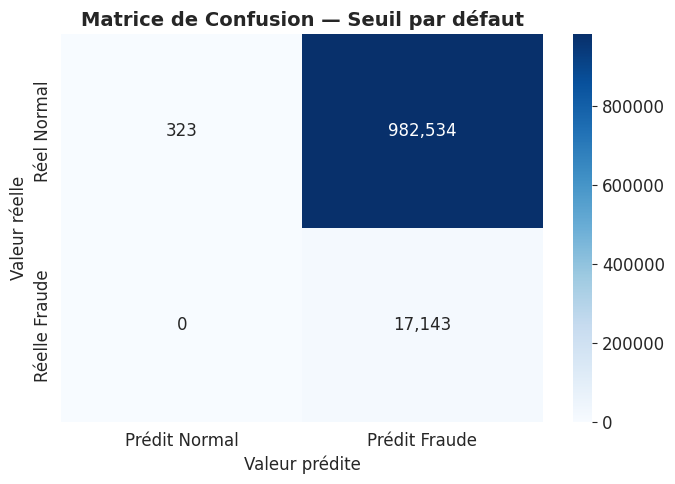

TN : 323 → normaux correctement classifiés
FP : 982,534 → normaux signalés comme fraude (fausses alarmes)
FN : 0 → fraudes manquées ⚠️
TP : 17,143 → fraudes correctement détectées ✅


In [26]:
cm = confusion_matrix(y, y_pred_binary)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Prédit Normal', 'Prédit Fraude'],
            yticklabels=['Réel Normal', 'Réelle Fraude'], ax=ax)
ax.set_title('Matrice de Confusion — Seuil par défaut',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Valeur réelle')
ax.set_xlabel('Valeur prédite')
plt.tight_layout()
plt.savefig(MODELS_PATH + 'if_confusion_matrix_default.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN : {tn:,} → normaux correctement classifiés')
print(f'FP : {fp:,} → normaux signalés comme fraude (fausses alarmes)')
print(f'FN : {fn:,} → fraudes manquées ⚠️')
print(f'TP : {tp:,} → fraudes correctement détectées ✅')

## 📈 7. Courbes ROC et Precision-Recall

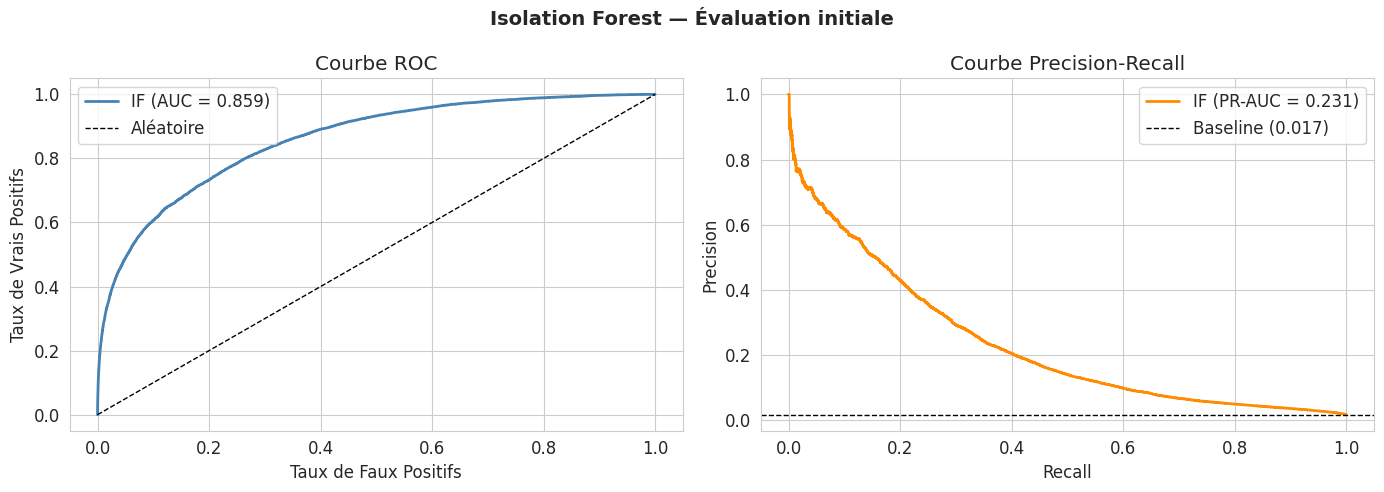

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y, scores_positifs)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'IF (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')
axes[0].set_xlabel('Taux de Faux Positifs')
axes[0].set_ylabel('Taux de Vrais Positifs')
axes[0].set_title('Courbe ROC')
axes[0].legend()
axes[0].grid(True)

precision_vals, recall_vals, _ = precision_recall_curve(y, scores_positifs)
axes[1].plot(recall_vals, precision_vals, color='darkorange', lw=2,
             label=f'IF (PR-AUC = {pr_auc:.3f})')
axes[1].axhline(y=y.mean(), color='k', linestyle='--', lw=1,
                label=f'Baseline ({y.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision-Recall')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Isolation Forest — Évaluation initiale',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS_PATH + 'if_roc_pr_curves.png', dpi=150)
plt.show()

## 🔧 8. Optimisation : contamination + seuil

Pour chaque valeur de contamination, on cherche le seuil qui maximise le F1-score sur les fraudes.

In [28]:
from sklearn.utils import resample

# Sous-échantillon stratifié pour l'optimisation
# On garde 10% du dataset → 100K lignes, beaucoup plus rapide
idx = resample(
    np.arange(len(y)),
    n_samples   = 100_000,
    stratify    = y,
    random_state= 42
)
X_sample = X_all[idx]
y_sample = y[idx]

contamination_values = [0.005, 0.01, 0.0171, 0.02, 0.03, 0.05]
comparison = []

print('🔍 Recherche de la meilleure contamination...')
for c in contamination_values:
    m = IsolationForest(
        n_estimators  = N_ESTIMATORS,
        contamination = c,
        random_state  = RANDOM_STATE,
        n_jobs        = -1
    )
    m.fit(X_normal)
    sc = -m.score_samples(X_sample)

    # Réduire à 100 seuils au lieu de tous
    _, _, thresholds_pr = precision_recall_curve(y_sample, sc)
    thresholds_reduced  = thresholds_pr[::max(1, len(thresholds_pr)//100)]

    f1s       = [f1_score(y_sample, (sc >= t).astype(int), zero_division=0)
                 for t in thresholds_reduced]
    best_f1_c = max(f1s)
    best_t_c  = thresholds_reduced[np.argmax(f1s)]
    auc_c     = roc_auc_score(y_sample, sc)
    pr_auc_c  = average_precision_score(y_sample, sc)

    comparison.append({
        'contamination' : c,
        'ROC-AUC'       : round(auc_c, 4),
        'PR-AUC'        : round(pr_auc_c, 4),
        'F1-optimal'    : round(best_f1_c, 4),
        'seuil_optimal' : round(float(best_t_c), 4),
        'fraudes_det'   : int((sc >= best_t_c).sum())
    })
    print(f'  c={c:.4f} | ROC-AUC={auc_c:.4f} | '
          f'PR-AUC={pr_auc_c:.4f} | F1={best_f1_c:.4f}')

comp_df = pd.DataFrame(comparison)
print('\n📊 Tableau comparatif :')
print(comp_df.to_string(index=False))

best_row = comp_df.loc[comp_df['F1-optimal'].idxmax()]
print(f'\n✅ Meilleure contamination : {best_row["contamination"]}')
print(f'   ROC-AUC               : {best_row["ROC-AUC"]}')
print(f'   PR-AUC                : {best_row["PR-AUC"]}')
print(f'   F1 optimal            : {best_row["F1-optimal"]}')
print(f'   Seuil optimal         : {best_row["seuil_optimal"]}')

🔍 Recherche de la meilleure contamination...
  c=0.0050 | ROC-AUC=0.8583 | PR-AUC=0.2484 | F1=0.3090
  c=0.0100 | ROC-AUC=0.8583 | PR-AUC=0.2484 | F1=0.3090
  c=0.0171 | ROC-AUC=0.8583 | PR-AUC=0.2484 | F1=0.3090
  c=0.0200 | ROC-AUC=0.8583 | PR-AUC=0.2484 | F1=0.3090
  c=0.0300 | ROC-AUC=0.8583 | PR-AUC=0.2484 | F1=0.3090
  c=0.0500 | ROC-AUC=0.8583 | PR-AUC=0.2484 | F1=0.3090

📊 Tableau comparatif :
 contamination  ROC-AUC  PR-AUC  F1-optimal  seuil_optimal  fraudes_det
        0.0050   0.8583  0.2484       0.309         0.5773         1490
        0.0100   0.8583  0.2484       0.309         0.5773         1490
        0.0171   0.8583  0.2484       0.309         0.5773         1490
        0.0200   0.8583  0.2484       0.309         0.5773         1490
        0.0300   0.8583  0.2484       0.309         0.5773         1490
        0.0500   0.8583  0.2484       0.309         0.5773         1490

✅ Meilleure contamination : 0.005
   ROC-AUC               : 0.8583
   PR-AUC             

In [29]:
print(f"Seuil utilisé         : {best_threshold}")
print(f"Score min             : {scores_final.min():.4f}")
print(f"Score max             : {scores_final.max():.4f}")
print(f"Score moyen           : {scores_final.mean():.4f}")
print(f"Scores > seuil        : {(scores_final >= best_threshold).sum()}")
print(f"Percentile 98.29%     : {np.percentile(scores_final, 98.29):.4f}")

Seuil utilisé         : 0.5767125823074258
Score min             : 0.4871
Score max             : 0.6041
Score moyen           : 0.5497
Scores > seuil        : 17143
Percentile 98.29%     : 0.5767


## 🏆 9. Modèle final avec meilleurs paramètres

In [30]:
# ─────────────────────────────────────────
# 9. Modèle final avec meilleurs paramètres
# ─────────────────────────────────────────
model_final = IsolationForest(
    n_estimators  = N_ESTIMATORS,
    contamination = best_row['contamination'],
    max_samples   = 'auto',
    random_state  = RANDOM_STATE,
    n_jobs        = -1
)
model_final.fit(X_normal)

scores_final = -model_final.score_samples(X_all)

print(f"Scores min    : {scores_final.min():.4f}")
print(f"Scores max    : {scores_final.max():.4f}")
print(f"Scores moyen  : {scores_final.mean():.4f}")

# Seuil basé sur le percentile du taux de fraude réel
# Si 1.71% de fraudes → seuil au percentile 98.29%
taux_fraude   = y.mean()
best_threshold = np.percentile(scores_final, (1 - taux_fraude) * 100)

print(f"\nTaux de fraude réel   : {taux_fraude*100:.2f}%")
print(f"Seuil percentile      : {best_threshold:.4f}")
print(f"Fraudes détectées     : {(scores_final >= best_threshold).sum():,}")
print(f"Fraudes réelles       : {int(y.sum()):,}")

y_pred_final = (scores_final >= best_threshold).astype(int)

roc_final = roc_auc_score(y, scores_final)
pr_final  = average_precision_score(y, scores_final)
f1_final  = f1_score(y, y_pred_final)

print('\n── Rapport final ──')
print(classification_report(y, y_pred_final,
      target_names=['Normal', 'Fraude']))

Scores min    : 0.4871
Scores max    : 0.6041
Scores moyen  : 0.5497

Taux de fraude réel   : 1.71%
Seuil percentile      : 0.5767
Fraudes détectées     : 17,143
Fraudes réelles       : 17,143

── Rapport final ──
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    982857
      Fraude       0.30      0.30      0.30     17143

    accuracy                           0.98   1000000
   macro avg       0.64      0.64      0.64   1000000
weighted avg       0.98      0.98      0.98   1000000



## 🔲 10. Matrice de confusion — seuil optimisé

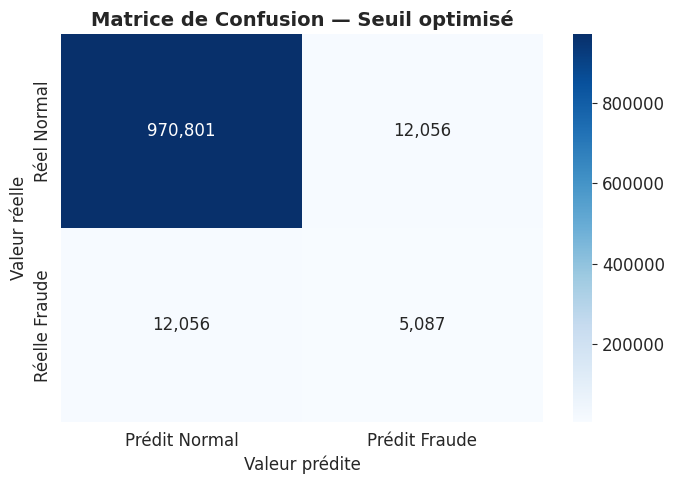

TN : 970,801 | FP : 12,056 | FN : 12,056 | TP : 5,087


In [31]:
cm_final = confusion_matrix(y, y_pred_final)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_final, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Prédit Normal', 'Prédit Fraude'],
            yticklabels=['Réel Normal', 'Réelle Fraude'], ax=ax)
ax.set_title('Matrice de Confusion — Seuil optimisé',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Valeur réelle')
ax.set_xlabel('Valeur prédite')
plt.tight_layout()
plt.savefig(MODELS_PATH + 'if_confusion_matrix_optimal.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm_final.ravel()
print(f'TN : {tn:,} | FP : {fp:,} | FN : {fn:,} | TP : {tp:,}')

## 📉 11. Distribution des scores d'anomalie

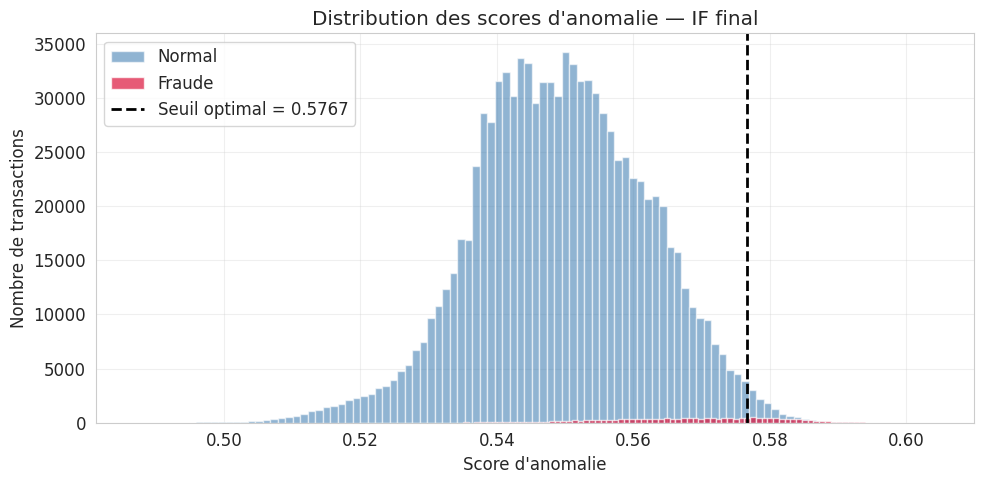

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scores_final[y.flatten() == 0], bins=100, alpha=0.6,
        label='Normal', color='steelblue')
ax.hist(scores_final[y.flatten() == 1], bins=100, alpha=0.7,
        label='Fraude', color='crimson')
ax.axvline(best_threshold, color='black', linestyle='--', lw=2,
           label=f'Seuil optimal = {best_threshold:.4f}')
ax.set_xlabel("Score d'anomalie")
ax.set_ylabel('Nombre de transactions')
ax.set_title("Distribution des scores d'anomalie — IF final")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_PATH + 'if_score_distribution.png', dpi=150)
plt.show()

## 💾 12. Sauvegarde du modèle

In [32]:
joblib.dump(model_final,    MODELS_PATH + 'isolation_forest.pkl')
joblib.dump(best_threshold, MODELS_PATH + 'isolation_forest_threshold.pkl')
np.save(BASE_PATH + 'if_scores.npy',    scores_final)
np.save(BASE_PATH + 'if_threshold.npy', np.array([best_threshold]))

# Test de rechargement
loaded_model     = joblib.load(MODELS_PATH + 'isolation_forest.pkl')
loaded_threshold = joblib.load(MODELS_PATH + 'isolation_forest_threshold.pkl')
test_scores      = -loaded_model.score_samples(X_all[:5])
test_pred        = (test_scores >= loaded_threshold).astype(int)
print(f'🔁 Test rechargement OK — prédictions : {test_pred}')

print('\n📁 Fichiers produits :')
print(f'   models/isolation_forest.pkl')
print(f'   models/isolation_forest_threshold.pkl')
print(f'   data/if_scores.npy')
print(f'   data/if_threshold.npy')
print(f'   models/if_confusion_matrix_default.png')
print(f'   models/if_confusion_matrix_optimal.png')
print(f'   models/if_roc_pr_curves.png')
print(f'   models/if_score_distribution.png')

🔁 Test rechargement OK — prédictions : [0 0 0 0 0]

📁 Fichiers produits :
   models/isolation_forest.pkl
   models/isolation_forest_threshold.pkl
   data/if_scores.npy
   data/if_threshold.npy
   models/if_confusion_matrix_default.png
   models/if_confusion_matrix_optimal.png
   models/if_roc_pr_curves.png
   models/if_score_distribution.png


## 📝 13. Résumé final

In [33]:
print('=' * 55)
print('       RÉSUMÉ FINAL — ISOLATION FOREST')
print('=' * 55)
print(f'  Dataset          : {len(y):,} transactions')
print(f'  Taux de fraude   : {y.mean()*100:.2f}%')
print(f'  Entraînement     : {X_normal.shape[0]:,} transactions normales')
print(f'  n_estimators     : {N_ESTIMATORS}')
print(f'  Contamination    : {best_row["contamination"]}')
print(f'  Seuil optimal    : {best_threshold:.4f}')
print('-' * 55)
print(f'  ROC-AUC          : {roc_final:.4f}')
print(f'  PR-AUC           : {pr_final:.4f}')
print(f'  F1-Score         : {f1_final:.4f}')
print('=' * 55)
print('\n→ Ces métriques sont à reporter dans le tableau comparatif')
print('  AE vs IF du notebook 05_comparaison.ipynb')

       RÉSUMÉ FINAL — ISOLATION FOREST
  Dataset          : 1,000,000 transactions
  Taux de fraude   : 1.71%
  Entraînement     : 982,857 transactions normales
  n_estimators     : 200
  Contamination    : 0.005
  Seuil optimal    : 0.5767
-------------------------------------------------------
  ROC-AUC          : 0.8586
  PR-AUC           : 0.2313
  F1-Score         : 0.2967

→ Ces métriques sont à reporter dans le tableau comparatif
  AE vs IF du notebook 05_comparaison.ipynb
